In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import networkx as nx
from dowhy import CausalModel
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import ElasticNetCV  
from sklearn.linear_model import LassoCV   

import warnings
warnings.filterwarnings('ignore')

/Users/alvarocorralescano/opt/anaconda3/envs/idealista/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
def draw_causal_graph(G, filename):
    """
    Draws a causal graph using networkx and matplotlib, and saves it to a file.

    Parameters:
        G (networkx.DiGraph): The directed graph to draw.
        filename (str): Path to save the image file.
    """
    plt.figure(figsize=(12, 8))
    pos = nx.circular_layout(G)
    node_sizes = [3000 if node == 'kwh_hh' else 2000 for node in G.nodes()]
    node_colors = ['lightgreen' if node == 'kwh_hh' else 'skyblue' for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='black')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=45, edge_color='gray', width=2)
    nx.draw_networkx_labels(G, pos, font_size=12, font_color='black', font_weight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

## Read data

In [47]:
df_daily = pd.read_csv('Processed data/valid_data_fe.csv')
df_daily.head()

,LCLid,Date,kwh_hh,treat,is_weekend,month_cos,day_of_week_cos,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,...,cloudcover,treat_2013,Acorn,Acorn_enc,got_high_signal,got_low_signal,high_signal_intensity,low_signal_intensity,Type,bank_holiday
0,MAC000006,2012-01-30,2.162,0,0,1.000000,1.000000,1,0,0,...,70.1,0,ACORN-Q,16.0,0,0,0,0,NaN,0
1,MAC000006,2012-01-31,3.906,0,0,1.000000,0.623490,0,0,0,...,65.0,0,ACORN-Q,16.0,0,0,0,0,NaN,0
2,MAC000006,2012-02-01,3.587,0,0,0.866025,-0.222521,0,0,0,...,35.0,0,ACORN-Q,16.0,0,0,0,0,New Year?s Day (substitute day),1
3,MAC000006,2012-02-02,3.416,0,0,0.866025,-0.900969,0,0,0,...,10.4,0,ACORN-Q,16.0,0,0,0,0,NaN,0
4,MAC000006,2012-02-03,3.739,0,0,0.866025,-0.900969,0,0,0,...,28.5,0,ACORN-Q,16.0,0,0,0,0,NaN,0


In [3]:
df_daily.columns

Index(['LCLid', 'Date', 'kwh_hh', 'treat', 'is_weekend', 'month_cos',
       'day_of_week_cos', 'day_of_week_Monday', 'day_of_week_Saturday',
       'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday',
       'day_of_week_Wednesday', 'month_2', 'month_3', 'month_4', 'month_5',
       'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11',
       'month_12', 'year_2013', 'temp', 'feelslike', 'precip', 'cloudcover',
       'treat_2013', 'Acorn', 'Acorn_enc', 'got_high_signal', 'got_low_signal',
       'high_signal_intensity', 'low_signal_intensity', 'Type',
       'bank_holiday'],
      dtype='object')

## DiD model

In [4]:
# Define dependent and independent variable matrices
X = df_daily.drop(columns=['LCLid', 'Date', 'kwh_hh', 'Acorn', 'got_high_signal', 'got_low_signal', 'high_signal_intensity', 'low_signal_intensity', 'is_weekend', 'Type'])
X = X.drop([col for col in X.columns if col.startswith('month')], axis=1) # Drop months
X = sm.add_constant(X)
y = df_daily['kwh_hh']

In [5]:
# Fit model
model = sm.OLS(y, X)
results = model.fit(cov_type='HC1')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 kwh_hh   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                    0.4798
Date:                Wed, 21 May 2025   Prob (F-statistic):              0.489
Time:                        13:39:08   Log-Likelihood:            -1.3489e+06
No. Observations:              376769   AIC:                         2.698e+06
Df Residuals:                  376753   BIC:                         2.698e+06
Df Model:                          15                                         
Covariance Type:                  HC1                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   2.66e+

## DoWhy + EconML model

### Step 1. Model

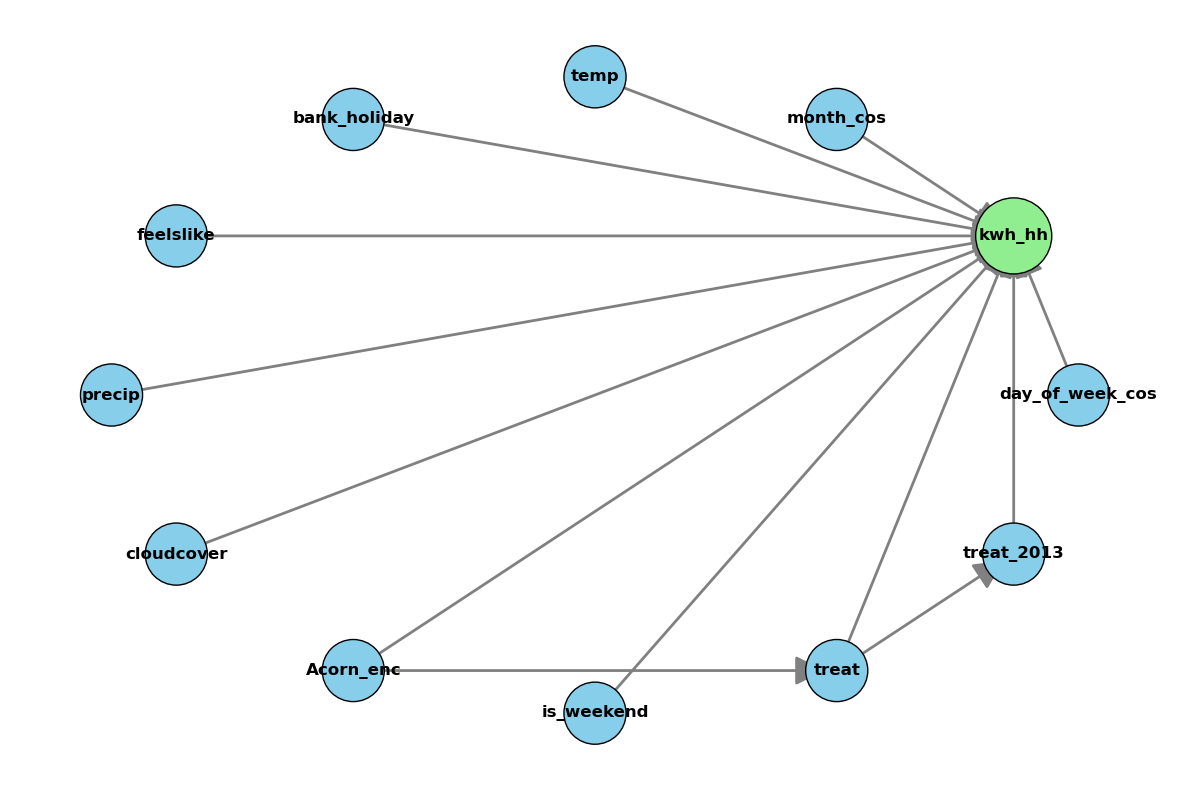

In [26]:
# Initialize directed graph
G = nx.DiGraph()

# List of causes
causes = ['day_of_week_cos', 'month_cos', 'temp', 'bank_holiday',
       'feelslike', 'precip', 'cloudcover', 'Acorn_enc', 'is_weekend'] 
       
# Add edges from each cause to 'kwh_hh'
for cause in causes:
    G.add_edge(cause, 'kwh_hh')

# Add the path from treat to treat_2013 to kwh_hh 
# Actual treatment variable is treat_2013, but treated households were already different in 2012
G.add_edges_from([
    ('treat', 'treat_2013'),
    ('treat_2013', 'kwh_hh'),
])

G.add_edges_from([
    ('treat', 'kwh_hh'),
])

# We have reasons to believe that treatment assignment may have depended on accorn status
G.add_edges_from([
    ('Acorn_enc', 'treat')
])

# # Condition the effect of bank holidays on temperature and precipitation
# G.add_edges_from([
#     ('temp', 'bank_holiday'),
#     ('precip', 'bank_holiday')
# ])

# Draw the causal graph
draw_causal_graph(G, 'Images/whole_network.png')

In [ ]:
model = CausalModel(
   data=df_daily, 
   treatment=['treat_2013'],  # Actual treatment, whose effect we want to quantify
   common_causes = ['treat'], # Treated households were already different in 2012
   effect_modifiers=causes,
   outcome="kwh_hh",
   graph="\n".join(nx.generate_gml(G))
)

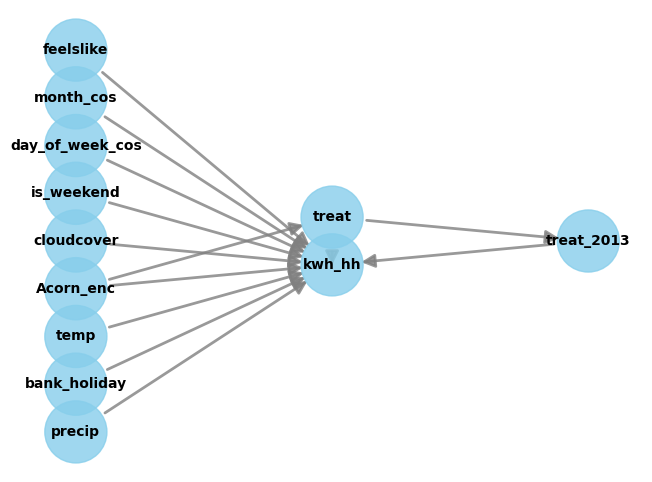

In [7]:
model.view_model()

### Step 2. Identify

In [8]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                       
────────────(E[kwh_hh|treat])
d[treat₂₀₁₃]                 
Estimand assumption 1, Unconfoundedness: If U→{treat_2013} and U→kwh_hh then P(kwh_hh|treat_2013,treat,U) = P(kwh_hh|treat_2013,treat)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



### Step 3. Estimate

In [34]:
dml_estimate = model.estimate_effect(identified_estimand, 
                                    method_name="backdoor.econml.dml.DML",
                                    control_value = 0,
                                    treatment_value = 1,
                                    #  target_units = lambda df_daily: df_daily["Acorn_enc"]>=15,  # condition used for CATE
                                    confidence_intervals=False,
                                    method_params={"init_params":{'model_y': GradientBoostingRegressor(random_state=42),
                                                                'model_t': GradientBoostingRegressor(random_state=42),
                                                                'featurizer':PolynomialFeatures(degree=2, include_bias=False),
                                                                'model_final': LassoCV(random_state=42),
                                                                'random_state': 42},
                                                    "fit_params":{}}
                                    )

# Alternative - simple linear regression as backdoor method
# dml_estimate = model.estimate_effect(identified_estimand, 
#                                     method_name="backdoor.linear_regression",
#                                     control_value = 0,
#                                     treatment_value = 1
#                                     )

print(dml_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                       
────────────(E[kwh_hh|treat])
d[treat₂₀₁₃]                 
Estimand assumption 1, Unconfoundedness: If U→{treat_2013} and U→kwh_hh then P(kwh_hh|treat_2013,treat,U) = P(kwh_hh|treat_2013,treat)

## Realized estimand
b: kwh_hh~treat_2013+treat | precip,bank_holiday,feelslike,temp,is_weekend,day_of_week_cos,month_cos,cloudcover
Target units: ate

## Estimate
Mean value: -0.26222953386742515
Effect estimates: [[-0.31027175]
 [-0.2667675 ]
 [-0.07734679]
 ...
 [-0.10254543]
 [-0.23803617]
 [-0.29800234]]



In [35]:
print('Effect value:', dml_estimate.value)

Effect value: -0.26222953386742515


In [50]:
dml_estimate.interpret()

Increasing the treatment variable(s) [treat_2013] from 0 to [1] causes an increase of -0.26222953386742515 in the expected value of the outcome [['kwh_hh']], over the data distribution/population represented by the dataset.


In [42]:
print('Individual CATE estimates:')
dml_estimate.params['cate_estimates']

Individual CATE estimates:


array([[-0.31027175],
       [-0.2667675 ],
       [-0.07734679],
       ...,
       [-0.10254543],
       [-0.23803617],
       [-0.29800234]])

In [49]:
list(dml_estimate.params['cate_estimates'])

[array([-0.31027175]),
 array([-0.2667675]),
 array([-0.07734679]),
 array([-0.00682925]),
 array([-0.05128566]),
 array([-0.19169439]),
 array([-0.36951245]),
 array([-0.25620351]),
 array([-0.17803084]),
 array([-0.63140237]),
 array([-0.51485117]),
 array([-0.10407784]),
 array([-0.0169822]),
 array([-0.2513998]),
 array([-0.30148263]),
 array([-0.30938716]),
 array([-0.2725442]),
 array([-0.34017181]),
 array([-0.2767083]),
 array([-0.23263957]),
 array([-0.02627644]),
 array([-0.19448771]),
 array([-0.34388951]),
 array([-0.4583375]),
 array([-0.15975048]),
 array([-0.36469801]),
 array([-0.15721982]),
 array([-0.1454751]),
 array([-0.37144707]),
 array([-0.35706056]),
 array([-0.47790845]),
 array([-0.24114772]),
 array([-0.2667675]),
 array([-0.27420605]),
 array([-0.37047913]),
 array([-0.27420605]),
 array([-0.28259107]),
 array([-0.23417514]),
 array([-0.25379597]),
 array([-0.40207955]),
 array([-0.32278867]),
 array([-0.20442346]),
 array([-0.22503749]),
 array([-0.53558137

### Step 4. Refute estimate
WARNING - High memory use. These three cells can take a lot of time to run.


In [12]:
# Adding a random common cause variable
res_random=model.refute_estimate(identified_estimand, dml_estimate, method_name="random_common_cause", show_progress_bar=True, n_jobs=-1)
print(res_random)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please cha

Refute: Add a random common cause
Estimated effect:-0.26222953386742515
New effect:-0.27636272854016136
p value:0.0



In [45]:
# Replacing treatment with a random (placebo) variable
res_placebo=model.refute_estimate(identified_estimand, dml_estimate,
        method_name="placebo_treatment_refuter", show_progress_bar=True, placebo_type="permute", n_jobs=-1)
print(res_placebo)




A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please 

Refute: Use a Placebo Treatment
Estimated effect:-0.26222953386742515
New effect:0.002195120704726658
p value:0.98



In [46]:
# Removing random subset of the data
res_subset=model.refute_estimate(identified_estimand, dml_estimate,
        method_name="data_subset_refuter", show_progress_bar=True, subset_fraction=0.9, n_jobs=-1)
print(res_subset)



A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please c

Refute: Use a subset of data
Estimated effect:-0.26222953386742515
New effect:-0.2680249700374532
p value:0.7



## Separate models for each type of price signal

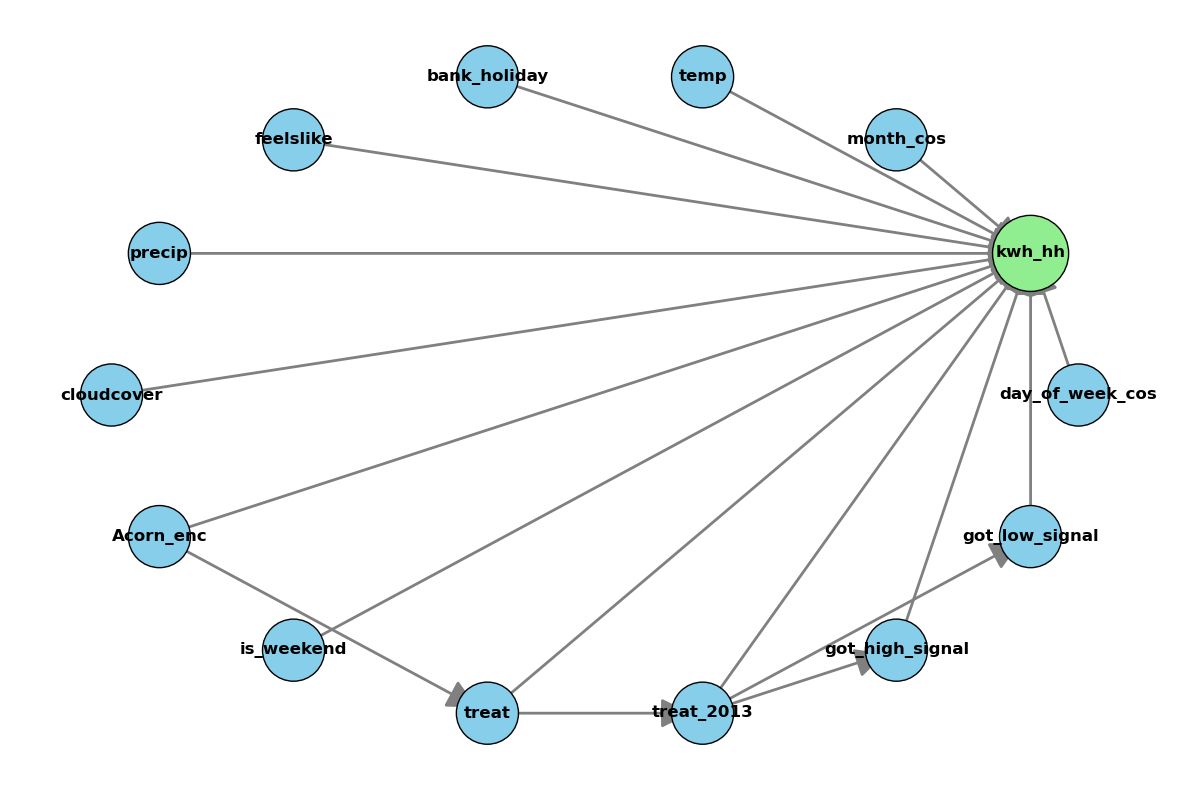

In [25]:
# Initialize new directed graph
G_alt = nx.DiGraph()

# List of causes
causes = causes = ['day_of_week_cos', 'month_cos', 'temp', 'bank_holiday',
       'feelslike', 'precip', 'cloudcover', 'Acorn_enc', 'is_weekend'] 
       
# Add edges from each cause to 'kwh_hh'
for cause in causes:
    G_alt.add_edge(cause, 'kwh_hh')

# Add the paths described in the question
# Path 1: treat to treatment in 2013 to getting high signal to consumption
G_alt.add_edges_from([
    ('treat', 'treat_2013'),
    ('treat_2013', 'got_high_signal'),
    ('got_high_signal', 'kwh_hh')
])

# Path 2: treat to treatment in 2013 to getting low signal to consumption
G_alt.add_edges_from([
    ('treat', 'treat_2013'),
    ('treat_2013', 'got_low_signal'),
    ('got_low_signal', 'kwh_hh')
])

# Even though our treatment here will be the type of signal received (if any), 
# knowing to be part of treatment group may have an impact on energy consumption
G_alt.add_edges_from([
    ('treat', 'treat_2013'),
    ('treat_2013', 'kwh_hh'),
])

# Again, treatment group was already different before 2013
G_alt.add_edges_from([
    ('treat', 'kwh_hh'),
])

# Again, it doesn't look like treatment was fully randomised
G_alt.add_edges_from([
    ('Acorn_enc', 'treat')
])

# Draw the alternative graph
draw_causal_graph(G_alt, 'Images/whole_network_signals.png')

In [16]:
# Low price signal model
# Step 1. Define model
model_low = CausalModel(
   data=df_daily, # some pandas dataframe
   treatment=['got_low_signal'],
   common_causes = ['treat', 'treat_2013'],
   effect_modifiers=causes,
   outcome="kwh_hh",
   graph="\n".join(nx.generate_gml(G_alt))
)

# Step 2. Identify estimand
identified_estimand_low = model_low.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_low)

# Step 3. Quantify causal estimate
causal_estimate_low = model_low.estimate_effect(identified_estimand_low, 
                                    method_name="backdoor.econml.dml.DML",
                                    control_value = 0,
                                    treatment_value = 1,
                                    confidence_intervals=False,
                                    method_params={"init_params":{'model_y': GradientBoostingRegressor(random_state=42),
                                                                'model_t': GradientBoostingRegressor(random_state=42),
                                                                'featurizer':PolynomialFeatures(degree=2, include_bias=False),
                                                                'model_final': ElasticNetCV(random_state=42),
                                                                'random_state': 42},
                                                    "fit_params":{}}
                                    )
print('Causal estimate value:', round(causal_estimate_low.value, 4))

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                              
─────────────────(E[kwh_hh|treat_2013])
d[got_low_signal]                      
Estimand assumption 1, Unconfoundedness: If U→{got_low_signal} and U→kwh_hh then P(kwh_hh|got_low_signal,treat_2013,U) = P(kwh_hh|got_low_signal,treat_2013)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

Causal estimate value: 0.2183


In [17]:
# High price signal model
# Step 1. Define model
model_high = CausalModel(
   data=df_daily, # some pandas dataframe
   treatment=['got_high_signal'],
   common_causes = ['treat', 'treat_2013'],
   effect_modifiers=causes.append('Acorn_enc'),
   outcome="kwh_hh",
   graph="\n".join(nx.generate_gml(G_alt))
)

# Step 2. Identify estimand
identified_estimand_high = model_high.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_high)

# Step 3. Quantify causal estimate
causal_estimate_high = model_high.estimate_effect(identified_estimand_high, 
                                    method_name="backdoor.econml.dml.DML",
                                    control_value = 0,
                                    treatment_value = 1,
                                    confidence_intervals=False,
                                    method_params={"init_params":{'model_y': GradientBoostingRegressor(random_state=42),
                                                                'model_t': GradientBoostingRegressor(random_state=42),
                                                                'featurizer':PolynomialFeatures(degree=2, include_bias=False),
                                                                'model_final': ElasticNetCV(random_state=42),
                                                                'random_state': 42},
                                                    "fit_params":{}}
                                    )
print('Causal estimate value:', round(causal_estimate_high.value, 4))
# print('Causal estimate value:', causal_estimate_high.get_confidence_intervals())

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                               
──────────────────(E[kwh_hh|treat_2013])
d[got_high_signal]                      
Estimand assumption 1, Unconfoundedness: If U→{got_high_signal} and U→kwh_hh then P(kwh_hh|got_high_signal,treat_2013,U) = P(kwh_hh|got_high_signal,treat_2013)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

Causal estimate value: -0.0709


## EXTRA - Calculating consumptions

In [18]:
treatment_effect = 0.262229533867425

# Keep only 2013
df_days = df_daily.copy()
df_days['Date'] = pd.to_datetime(df_days['Date'])
df_days = df_days[df_days['Date'].dt.year == 2013]

# Add "saved energy" to treated households
df_days['kwh_hh_alt'] = np.where(df_days['treat'] == 1, df_days['kwh_hh'] + treatment_effect, df_days['kwh_hh'])

In [19]:
# Consumption totals 
actual_cons = df_days['kwh_hh'][df_days['treat']==1].sum()          # Actual consumption
potential_cons = df_days['kwh_hh_alt'][df_days['treat']==1].sum()   # Counterfactual consumption - what would have been consumed where it not for the DToU tariff
diff_cons = actual_cons - potential_cons                            # Difference between actual and counterfactual consumption

print('Actual consumption:', actual_cons)
print('Potential consumption:', potential_cons)

Actual consumption: 275812.3200001
Potential consumption: 283180.7076722408


In [20]:
# Per household totals
print('Average expenditure difference:', diff_cons * 14.228 / 100 / 77)
print('Average energy difference:', diff_cons / 77)

Average expenditure difference: -13.615249324573913
Average energy difference: -95.6933463914388


In [21]:
# Average household consumption in 2013
total_cons = df_days.groupby(['LCLid'])['kwh_hh'].sum()
total_cons.mean()